# EDS Analysis

This notebook provides a compact, reproducible analysis pipeline for Embedding-based Dialectality Scores.

It performs the following steps:

1. load embedding data and external standard reference data,
2. compute segment-level dialect scores,
3. aggregate segment-level scores to the speaker × situation level,
4. optimize a combined score against aggregated D-values,
5. evaluate correlations overall and by situation,
6. report separation metrics and dialect-level summaries.

Private paths are intentionally replaced by placeholders.


In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from ast import literal_eval
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LogisticRegression
from scipy.spatial.distance import cityblock, cosine, euclidean


In [ ]:
# =========================================================
# CONFIG
# =========================================================

STANDARD_CENTER_METHOD = "mean"          # {"mean", "median", "geometric_median"}
SEGMENT_AGGREGATION = "median"           # {"mean", "median"}
DISTANCE_METRIC = "cityblock"            # {"cityblock", "euclidean", "cosine"}

MAIN_EMBEDDINGS_PATH = Path(r"...\embeddings.pkl")
STANDARD_REFERENCE_PATHS = [
    Path(r"...\Bundestag\embeddings.pkl"),
]
D_VALUES_PATH = Path("data/d_values.csv")
FINAL_RESULTS_PATH = Path(r"...\Bundestag\final_analysis.csv")

EMBEDDING_SOURCE_COLUMN = "trillsson"

RECORDING_CONDITION_RULES = {
    "dialect": r"dialekt\.wav$",
    "standard": r"standard\.wav$",
    "TEST": r"test\d*\.wav$",
}
DEFAULT_RECORDING_CONDITION = "FG"

GENERATION_RULES = {
    "ALT": r"ALT\d*",
    "JUNG": r"JUNG\d*",
    "TEST": r"test\d*",
}
DEFAULT_GENERATION = "MITTEL"

# =========================================================
EMBEDDING_COLUMN = "embedding"
RANDOM_STATE = 42

DIALECT_MAPPING = {
    "Bairisch": "Bavarian",
    "Brandenburgisch": "Brandenburgian",
    "Hochalemannisch": "High Alemannic",
    "Mecklenburgisch-Vorpommersch": "Mecklenburgish Pomeranian",
    "Mittelalemannisch": "Middle Alemannic",
    "Moselfraenkisch": "Moselle Franconian",
    "Niederfraenkisch": "Low Franconian",
    "Nordhessisch": "North Hessian",
    "Nordniederdeutsch": "Northern Low German",
    "Ostfaelisch": "East Phalian",
    "Ostfraenkisch": "East Franconian",
    "Osthessisch": "East Hessian",
    "Ostmitteldeutsch": "East Middle German",
    "Rheinfraenkisch": "Rhine Franconian",
    "Ripuarisch": "Ripuarian",
    "Schwaebisch": "Swabian",
    "Westfaelisch": "Westphalian",
    "Zentralhessisch": "Central Hessian",
}

D_VALUE_SITUATION_MAPPING = {
    "WS_Standard": "standard",
    "WS_Dialekt": "dialect",
    "standard": "standard",
    "dialect": "dialect",
    "FG": "FG",
}

SITUATION_LABELS = {
    "standard": "WSS",
    "dialect": "WSD",
    "FG": "FG",
}

DIALECT_ABBR = {
    "High Alemannic": "HA",
    "Middle Alemannic": "MA",
    "Swabian": "S",
    "Northern Low German": "NLG",
    "Bavarian": "B",
    "Ripuarian": "R",
    "Rhine Franconian": "RF",
    "East Hessian": "EH",
    "Moselle Franconian": "MF",
    "East Middle German": "EMG",
    "Central Hessian": "CH",
    "East Franconian": "EF",
    "Mecklenburgish Pomeranian": "MP",
    "Brandenburgian": "BB",
    "East Phalian": "EP",
    "Westphalian": "WP",
    "North Hessian": "NH",
    "Low Franconian": "LF",
}


In [3]:
def infer_recording_condition(file_name: str) -> str:
    file_name = str(file_name).strip().lower()

    for label, pattern in RECORDING_CONDITION_RULES.items():
        if re.search(pattern, file_name):
            return label

    return DEFAULT_RECORDING_CONDITION


def infer_generation_label(speaker_name: str) -> str:
    speaker_name = str(speaker_name)

    for label, pattern in GENERATION_RULES.items():
        if re.search(pattern, speaker_name, flags=re.IGNORECASE):
            return label

    return DEFAULT_GENERATION


def ensure_embedding_column(
    frame: pd.DataFrame,
    source_column: str = EMBEDDING_SOURCE_COLUMN,
    target_column: str = EMBEDDING_COLUMN,
) -> pd.DataFrame:
    frame = frame.copy()
    frame.rename(columns={source_column: target_column}, inplace=True)
    first_value = frame[target_column].iloc[0]
    if isinstance(first_value, str):
        frame[target_column] = frame[target_column].apply(literal_eval).apply(np.asarray)
    else:
        frame[target_column] = frame[target_column].apply(np.asarray)
    return frame


def geometric_median(values: np.ndarray, tolerance: float = 1e-5, max_iter: int = 1000) -> np.ndarray:
    estimate = np.mean(values, axis=0)
    for _ in range(max_iter):
        distances = np.linalg.norm(values - estimate, axis=1)
        nonzero_mask = distances != 0
        if not np.any(nonzero_mask):
            return estimate
        inv_distances = 1.0 / distances[nonzero_mask]
        weights = inv_distances / inv_distances.sum()
        updated = (values[nonzero_mask] * weights[:, None]).sum(axis=0)
        if np.linalg.norm(estimate - updated) < tolerance:
            return updated
        estimate = updated
    return estimate


def compute_center(values: np.ndarray, method: str) -> np.ndarray:
    if method == "mean":
        return np.mean(values, axis=0)
    if method == "median":
        return np.median(values, axis=0)
    if method == "geometric_median":
        return geometric_median(values)
    raise ValueError(f"Unknown center method: {method}")


def compute_distance(a: np.ndarray, b: np.ndarray, metric: str) -> float:
    if metric == "cityblock":
        return cityblock(a, b)
    if metric == "euclidean":
        return euclidean(a, b)
    if metric == "cosine":
        return cosine(a, b)
    raise ValueError(f"Unknown distance metric: {metric}")


def safe_correlation(x: np.ndarray, y: np.ndarray) -> dict:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {
            "n": len(x),
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
        }

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    return {
        "n": len(x),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
    }


def aggregate_scores(
    frame: pd.DataFrame,
    score_column: str,
    aggregation: str = SEGMENT_AGGREGATION,
) -> pd.DataFrame:
    aggregated = (
        frame.dropna(subset=[score_column, "speaker", "recording_condition"])
        .groupby(["speaker", "dialect", "recording_condition"], as_index=False)[score_column]
        .agg(aggregation)
        .rename(columns={score_column: f"{score_column}_agg"})
    )
    return aggregated


def format_condition_label(condition: str) -> str:
    return SITUATION_LABELS.get(condition, condition)


def print_correlation_result(title: str, result: dict) -> None:
    print(title)
    print(
        f"Pearson r = {result['pearson_r']:.3f}, "
        f"p = {result['pearson_p']:.3g}, "
        f"N = {result['n']}"
    )
    print(
        f"Spearman rho = {result['spearman_rho']:.3f}, "
        f"p = {result['spearman_p']:.3g}"
    )
    print()


def fit_line(x: np.ndarray, y: np.ndarray):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return None, None
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(np.min(x), np.max(x), 200)
    y_line = slope * x_line + intercept
    return x_line, y_line


def cohens_d(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    pooled_std = np.sqrt(
        (((len(x) - 1) * np.var(x, ddof=1)) + ((len(y) - 1) * np.var(y, ddof=1)))
        / (len(x) + len(y) - 2)
    )
    if pooled_std == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled_std


def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    greater = 0
    less = 0
    for value in x:
        greater += np.sum(value > y)
        less += np.sum(value < y)
    return (greater - less) / (len(x) * len(y))


def save_results_table(frame: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    suffix = path.suffix.lower()

    if suffix == ".parquet":
        frame.to_parquet(path, index=False)
    elif suffix == ".csv":
        frame.to_csv(path, index=False)
    elif suffix in {".xlsx", ".xls"}:
        frame.to_excel(path, index=False)
    else:
        raise ValueError("Use a .parquet, .csv, or .xlsx output path.")

    print(f"Saved final analysis table to: {path}")


## 1. Load embedding data

In [4]:
def load_main_embeddings(path: Path) -> pd.DataFrame:
    frame = pd.read_pickle(path).copy()
    frame["dialect"] = frame["dialect"].replace(DIALECT_MAPPING)
    frame["recording_condition"] = frame["file_name"].apply(infer_recording_condition)
    frame["generation"] = frame["speaker"].apply(infer_generation_label)
    frame = ensure_embedding_column(frame)
    return frame


def load_standard_reference(paths: list[Path]) -> np.ndarray:
    reference_vectors = []
    for path in paths:
        frame = pd.read_pickle(path).copy()
        frame = ensure_embedding_column(frame)
        reference_vectors.append(np.stack(frame[EMBEDDING_COLUMN].values))

    if not reference_vectors:
        raise ValueError("STANDARD_REFERENCE_PATHS must contain at least one valid path.")

    if len(reference_vectors) == 1:
        return reference_vectors[0]

    return np.concatenate(reference_vectors, axis=0)


main_df = load_main_embeddings(MAIN_EMBEDDINGS_PATH)
standard_reference_embeddings = load_standard_reference(STANDARD_REFERENCE_PATHS)

print(f"Main segments: {len(main_df):,}")
print(f"Reference standard embeddings: {len(standard_reference_embeddings):,}")


Main segments: 25,289
Reference standard embeddings: 2,000


## 2. Estimate the global standard reference and projection direction

In [5]:
global_standard_center = compute_center(
    standard_reference_embeddings,
    method=STANDARD_CENTER_METHOD,
)

reference_distances = np.array(
    [compute_distance(x, global_standard_center, DISTANCE_METRIC) for x in standard_reference_embeddings]
)
reference_distance_mean = np.mean(reference_distances)
reference_distance_std = np.std(reference_distances)

training_df = main_df[main_df["recording_condition"].isin(["standard", "dialect"])].copy()
X_train = np.stack(training_df[EMBEDDING_COLUMN].values)
y_train = (training_df["recording_condition"] == "dialect").astype(int).to_numpy()

classifier = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
classifier.fit(X_train, y_train)

projection_direction = classifier.coef_[0]
projection_direction = projection_direction / np.linalg.norm(projection_direction)

reference_projection_scores = np.array(
    [np.dot(x - global_standard_center, projection_direction) for x in standard_reference_embeddings]
)
reference_projection_mean = np.mean(reference_projection_scores)
reference_projection_std = np.std(reference_projection_scores)

print("Reference statistics computed.")


Reference statistics computed.


## 3. Compute segment-level scores

In [6]:
def compute_segment_scores(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()

    distance_values = []
    distance_z_values = []
    projection_z_values = []

    for embedding in frame[EMBEDDING_COLUMN]:
        distance_to_standard = compute_distance(embedding, global_standard_center, DISTANCE_METRIC)
        projection_score = np.dot(embedding - global_standard_center, projection_direction)

        distance_z = (
            (distance_to_standard - reference_distance_mean) / reference_distance_std
            if np.isfinite(reference_distance_std) and reference_distance_std > 0
            else np.nan
        )
        projection_z = (
            (projection_score - reference_projection_mean) / reference_projection_std
            if np.isfinite(reference_projection_std) and reference_projection_std > 0
            else np.nan
        )

        distance_values.append(distance_to_standard)
        distance_z_values.append(distance_z)
        projection_z_values.append(projection_z)

    frame["distance_to_standard_center"] = distance_values
    frame["distance_z"] = distance_z_values
    frame["projection_z"] = projection_z_values

    return frame


segment_scores_df = compute_segment_scores(main_df)
segment_scores_df.head()


,dialect,file_name,embedding,file_path,speaker,samples_begin,samples_end,recording_condition,generation,distance_to_standard_center,distance_z,projection_z
0,Bavarian,AM2_FG.wav,"[0.0045728423, -0.104548596, -0.021386456, 0.0...",D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,0,159999,FG,MITTEL,12.685152,1.503326,2.120370
1,Bavarian,AM2_FG.wav,"[0.008114638, -0.10834301, -0.04026192, 0.0082...",D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,160000,319999,FG,MITTEL,14.906372,2.450365,2.174787
2,Bavarian,AM2_FG.wav,"[0.012570917, -0.05652473, -0.006772019, 0.009...",D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,320000,479999,FG,MITTEL,13.581022,1.885289,1.738227
3,Bavarian,AM2_FG.wav,"[0.011619878, -0.046208337, -0.03810372, 0.004...",D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,480000,639999,FG,MITTEL,14.867779,2.433911,2.012678
4,Bavarian,AM2_FG.wav,"[0.0072708973, -0.044305667, -0.006979473, 0.0...",D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,640000,799999,FG,MITTEL,11.822205,1.135400,2.331814


## 4. Load and aggregate D-values

In [7]:
d_values_df = pd.read_csv(D_VALUES_PATH).copy()
d_values_df["recording_condition"] = d_values_df["situation"].map(D_VALUE_SITUATION_MAPPING)
d_values_df = d_values_df[d_values_df["recording_condition"].isin(["standard", "dialect", "FG"])].copy()
d_values_df.rename(columns={"sprecher": "speaker", "dialekt": "dialect", "value": "d_value"}, inplace=True)
d_values_df.drop(columns=["situation"], inplace=True)

print(f"D-Values: {len(d_values_df):,}")
d_values_df.head()


D-Values: 525


,speaker,d_value,dialect,recording_condition
0,KFALT3,2.5,Swabian,FG
3,KFALT3,2.7,Swabian,dialect
4,KFALT3,1.1,Swabian,standard
5,KF1,1.9,Swabian,FG
8,KF1,2.6,Swabian,dialect


## 5. Find the best linear combination of distance and projection scores

In [8]:
candidate_weights = np.linspace(0.0, 1.0, 21)
pearson_scores = []
spearman_scores = []

for weight in candidate_weights:
    trial_df = segment_scores_df.copy()
    trial_df["combined_score"] = (
        weight * trial_df["distance_z"] + (1.0 - weight) * trial_df["projection_z"]
    )

    aggregated_trial_df = aggregate_scores(trial_df, score_column="combined_score")
    correlation_df = aggregated_trial_df.merge(
        d_values_df,
        on=["speaker", "recording_condition"],
        how="inner",
    )

    result = safe_correlation(
        correlation_df["combined_score_agg"].to_numpy(),
        correlation_df["d_value"].to_numpy(),
    )
    pearson_scores.append(result["pearson_r"])
    spearman_scores.append(result["spearman_rho"])

best_weight_index = int(np.nanargmax(pearson_scores))
best_weight = float(candidate_weights[best_weight_index])

segment_scores_df["combined_score"] = (
    best_weight * segment_scores_df["distance_z"] + (1.0 - best_weight) * segment_scores_df["projection_z"]
)
segment_scores_df["combined_score"] = segment_scores_df["combined_score"]

print(f"Best weight on distance_z: {best_weight:.2f}")
print(f"Best Pearson correlation: {pearson_scores[best_weight_index]:.3f}")


Best weight on distance_z: 0.35
Best Pearson correlation: 0.686


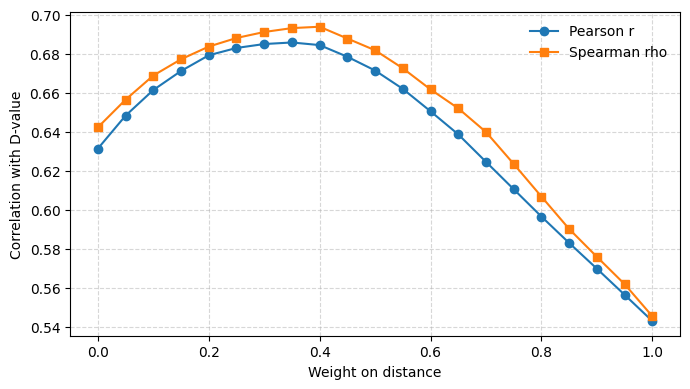

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(candidate_weights, pearson_scores, marker="o", label="Pearson r")
plt.plot(candidate_weights, spearman_scores, marker="s", label="Spearman rho")
plt.xlabel("Weight on distance")
plt.ylabel("Correlation with D-value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 6. Correlation analysis, separation metrics, and diagnostic plots

In [10]:
combined_scores_agg_df = aggregate_scores(segment_scores_df, score_column="combined_score")

analysis_df = combined_scores_agg_df.merge(
    d_values_df,
    on=["speaker", "recording_condition"],
    how="inner",
)
analysis_df["generation"] = analysis_df["speaker"].apply(infer_generation_label)
analysis_df["situation"] = analysis_df["recording_condition"].map(format_condition_label)

overall_result = safe_correlation(
    analysis_df["combined_score_agg"].to_numpy(),
    analysis_df["d_value"].to_numpy(),
)
print_correlation_result("Overall correlation", overall_result)

condition_results = []
for condition in ["standard", "dialect", "FG"]:
    subset = analysis_df[analysis_df["recording_condition"] == condition].copy()
    result = safe_correlation(
        subset["combined_score_agg"].to_numpy(),
        subset["d_value"].to_numpy(),
    )
    print_correlation_result(f"{format_condition_label(condition)} correlation", result)
    condition_results.append(
        {
            "situation": format_condition_label(condition),
            **result,
        }
    )

condition_results_df = pd.DataFrame(condition_results)
condition_results_df


Overall correlation
Pearson r = 0.686, p = 7.03e-61, N = 429
Spearman rho = 0.693, p = 1.11e-62

WSS correlation
Pearson r = 0.474, p = 1.34e-09, N = 147
Spearman rho = 0.462, p = 3.97e-09

WSD correlation
Pearson r = 0.570, p = 4.27e-13, N = 136
Spearman rho = 0.514, p = 1.56e-10

FG correlation
Pearson r = 0.583, p = 1.09e-14, N = 146
Spearman rho = 0.560, p = 2.03e-13



,situation,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,WSS,147,0.473854,1.343828e-09,0.461672,3.966411e-09
1,WSD,136,0.570245,4.273168e-13,0.513977,1.556528e-10
2,FG,146,0.583483,1.086747e-14,0.559889,2.027015e-13


In [11]:
stratified_results = []

for generation in ["JUNG", "MITTEL", "ALT"]:
    for condition in ["standard", "dialect", "FG"]:
        subset = analysis_df[
            (analysis_df["generation"] == generation)
            & (analysis_df["recording_condition"] == condition)
        ].copy()

        result = safe_correlation(
            subset["combined_score_agg"].to_numpy(),
            subset["d_value"].to_numpy(),
        )

        stratified_results.append(
            {
                "generation": generation,
                "situation": format_condition_label(condition),
                "n": result["n"],
                "pearson_r": result["pearson_r"],
                "pearson_p": result["pearson_p"],
                "spearman_rho": result["spearman_rho"],
                "spearman_p": result["spearman_p"],
            }
        )

stratified_results_df = pd.DataFrame(stratified_results)
stratified_results_df


,generation,situation,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,JUNG,WSS,47,0.315356,3.083597e-02,0.383418,7.806663e-03
1,JUNG,WSD,38,0.438010,5.952856e-03,0.410201,1.053192e-02
2,JUNG,FG,47,0.297128,4.253828e-02,0.254295,8.454577e-02
3,MITTEL,WSS,51,0.417925,2.276375e-03,0.435999,1.383203e-03
4,MITTEL,WSD,48,0.763098,2.875927e-10,0.742874,1.488335e-09
5,MITTEL,FG,51,0.689431,2.211598e-08,0.683544,3.241984e-08
6,ALT,WSS,49,0.472589,6.063672e-04,0.427771,2.169875e-03
7,ALT,WSD,50,0.404045,3.614743e-03,0.321591,2.276575e-02
8,ALT,FG,48,0.411537,3.660480e-03,0.381409,7.478099e-03


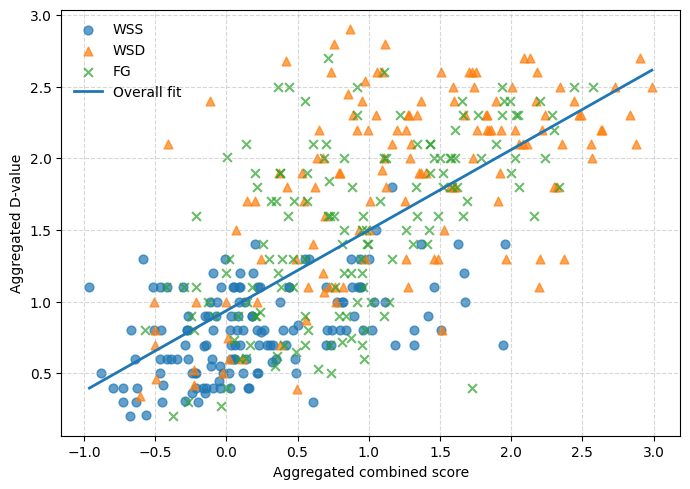

In [12]:
plt.figure(figsize=(7, 5))

for condition, marker in [("standard", "o"), ("dialect", "^"), ("FG", "x")]:
    subset = analysis_df[analysis_df["recording_condition"] == condition]
    plt.scatter(
        subset["combined_score_agg"],
        subset["d_value"],
        alpha=0.7,
        s=40,
        marker=marker,
        label=format_condition_label(condition),
    )

x = analysis_df["combined_score_agg"].to_numpy()
y = analysis_df["d_value"].to_numpy()
x_line, y_line = fit_line(x, y)
if x_line is not None:
    plt.plot(x_line, y_line, linewidth=2, label="Overall fit")

plt.xlabel("Aggregated combined score")
plt.ylabel("Aggregated D-value")
plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


WSS vs WSD separation (segment-level combined_score)
Cohen's d = 1.166
Cliff's delta = 0.587
AUC = 0.793
N_WSS = 8372, N_WSD = 8347


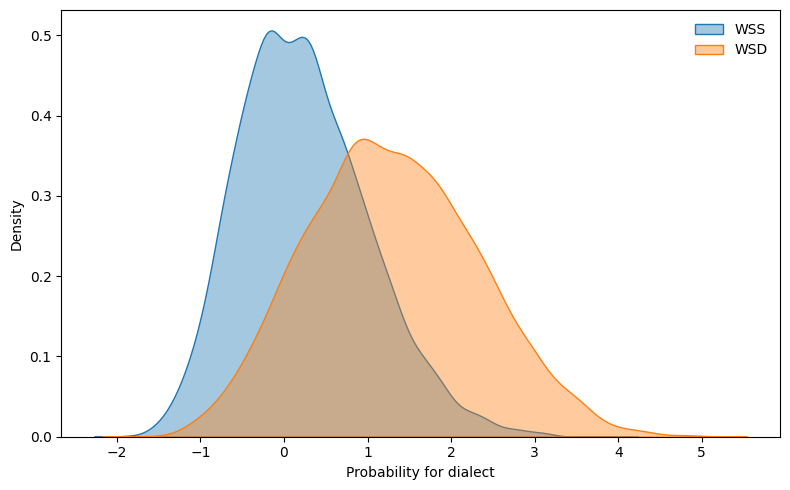

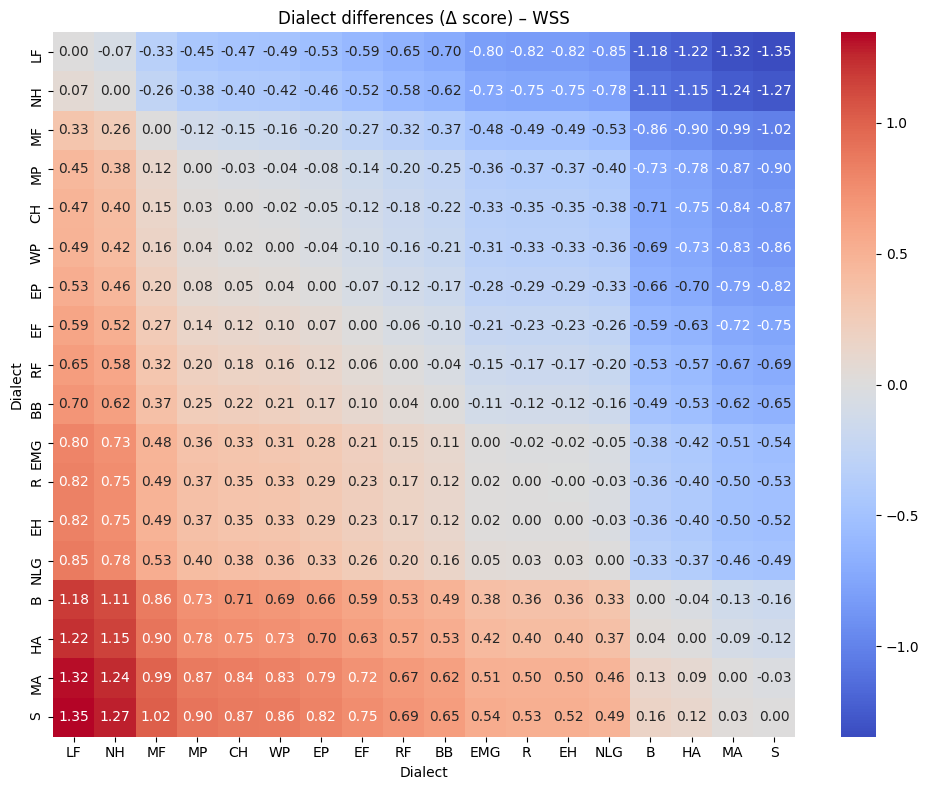

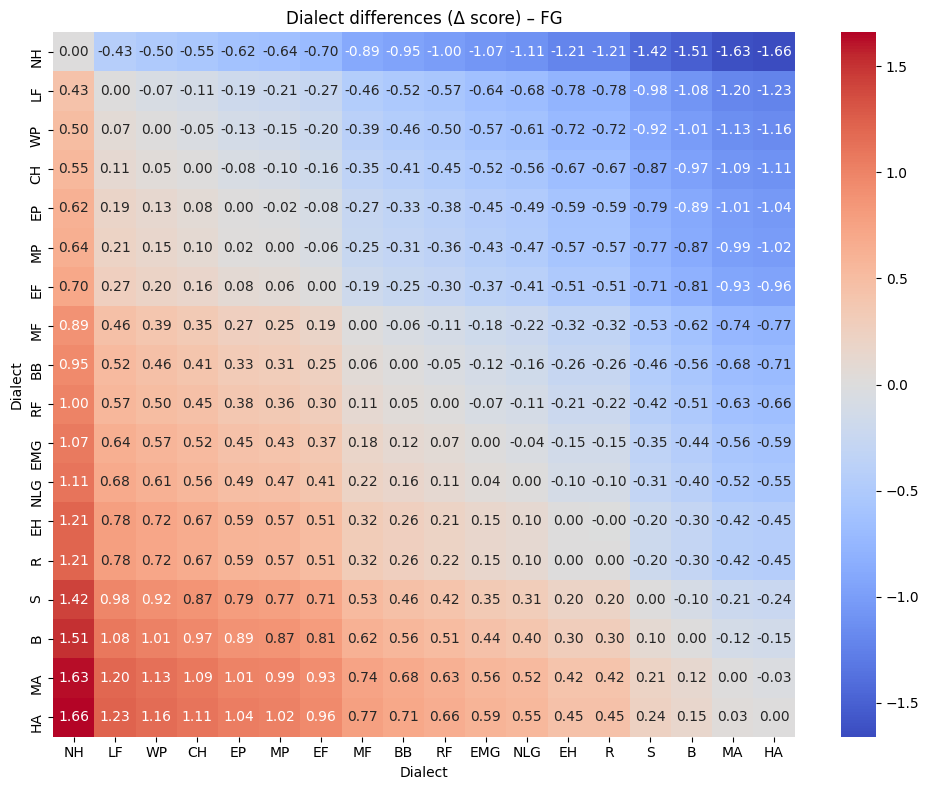

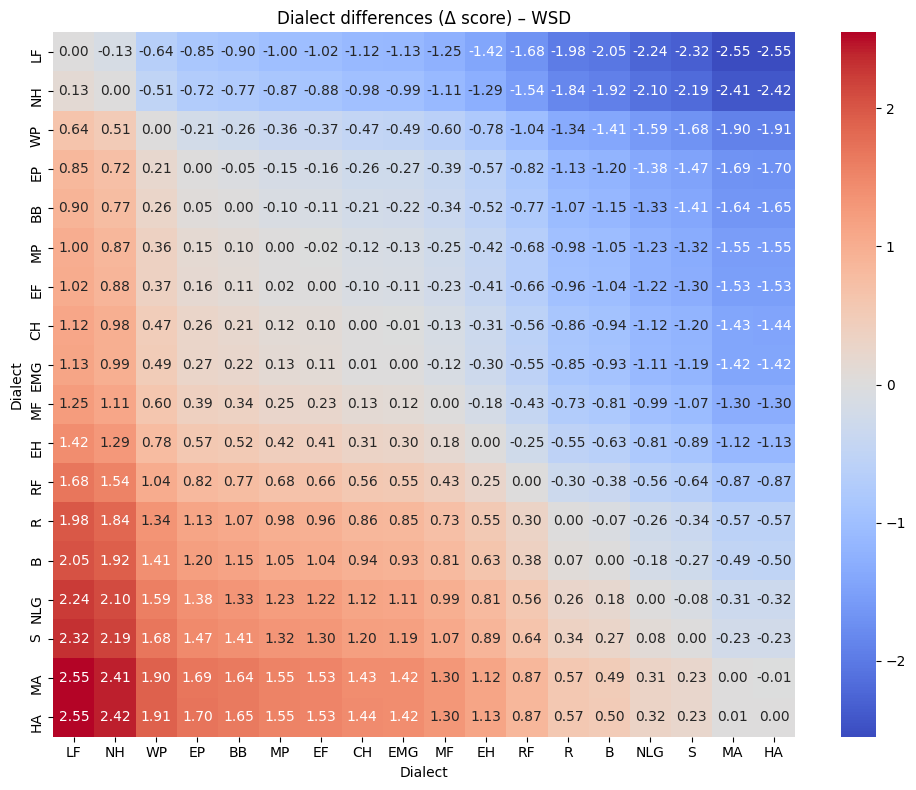

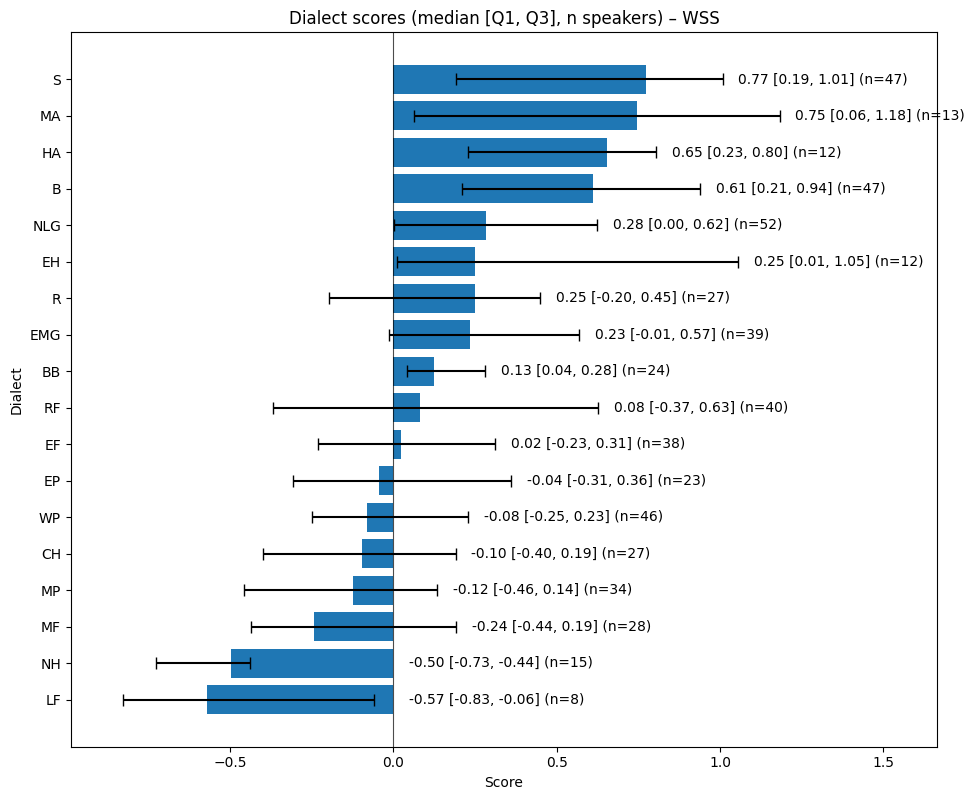

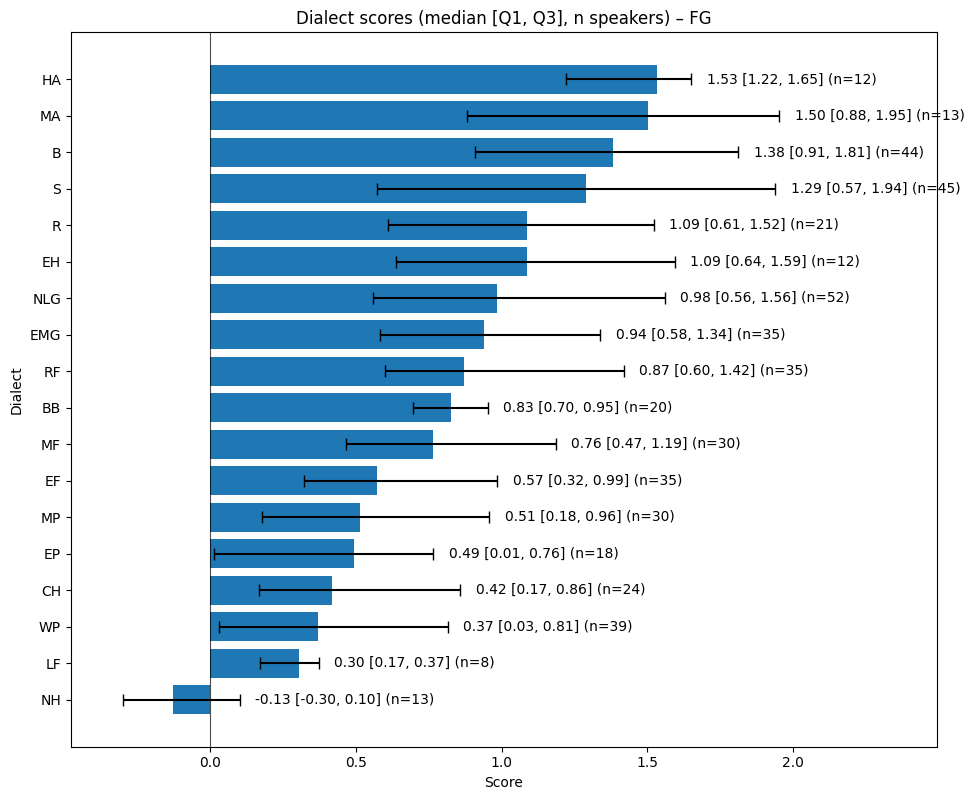

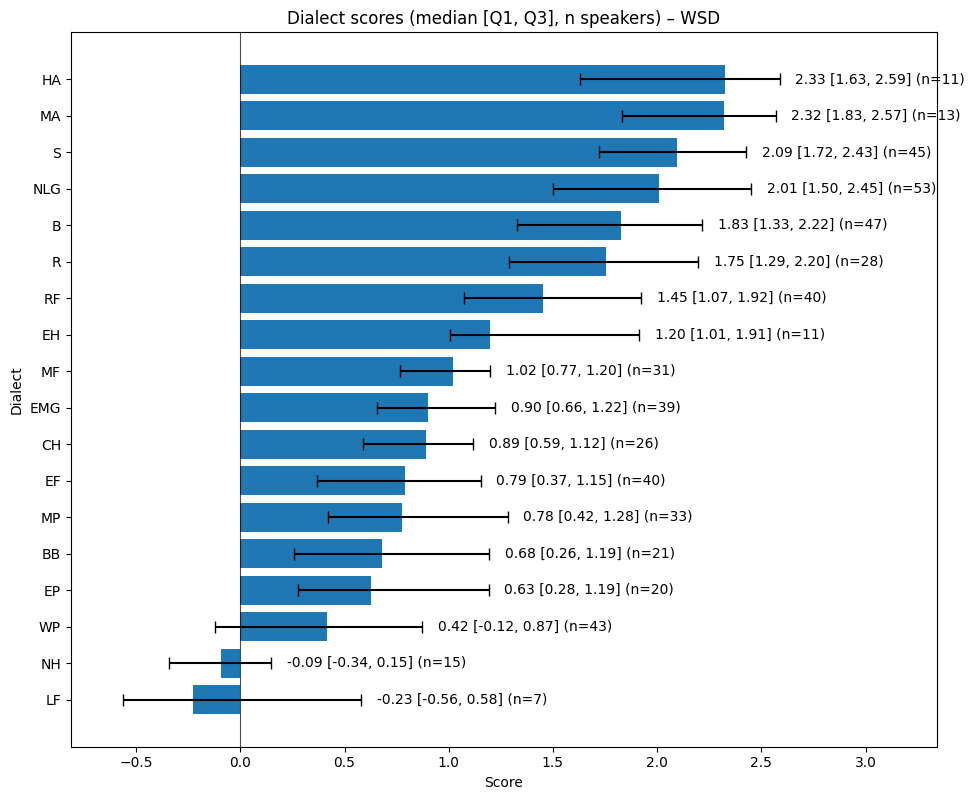

In [13]:
# Separation metrics for the original segment-level EDS score (WSS vs WSD)
separation_df = segment_scores_df[segment_scores_df["recording_condition"].isin(["standard", "dialect"])].copy()

x = separation_df.loc[separation_df["recording_condition"] == "standard", "combined_score"].dropna().to_numpy()
y = separation_df.loc[separation_df["recording_condition"] == "dialect", "combined_score"].dropna().to_numpy()

labels = np.concatenate([np.zeros(len(x)), np.ones(len(y))])
scores = np.concatenate([x, y])

print("WSS vs WSD separation (segment-level combined_score)")
print(f"Cohen's d = {cohens_d(y, x):.3f}")
print(f"Cliff's delta = {cliffs_delta(y, x):.3f}")
print(f"AUC = {roc_auc_score(labels, scores):.3f}")
print(f"N_WSS = {len(x)}, N_WSD = {len(y)}")

plt.figure(figsize=(8, 5))
for label in ["standard", "dialect"]:
    subset = separation_df.loc[separation_df["recording_condition"] == label, "combined_score"].dropna()
    sns.kdeplot(
        subset,
        label=format_condition_label(label),
        fill=True,
        alpha=0.4,
    )
plt.xlabel("Probability for dialect")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# Dialect-level plots in the original style, based on speaker × dialect × situation
CLS_MAP = {"standard": "WSS", "dialect": "WSD", "FG": "FG"}
CLS_ORDER = ["WSS", "FG", "WSD"]

dialect_plot_df = segment_scores_df.copy()
dialect_plot_df["speaker"] = dialect_plot_df["speaker"].astype(str).str.upper().str.strip()
dialect_plot_df["dialect"] = dialect_plot_df["dialect"].astype(str).str.strip()
dialect_plot_df["Situation"] = dialect_plot_df["recording_condition"].map(CLS_MAP)

dialect_plot_df["combined_score"] = pd.to_numeric(dialect_plot_df["combined_score"], errors="coerce")
dialect_plot_df = dialect_plot_df.dropna(subset=["speaker", "dialect", "Situation", "combined_score"]).copy()

df_spk = (
    dialect_plot_df.groupby(["speaker", "dialect", "Situation"], as_index=False)["combined_score"]
    .agg(SEGMENT_AGGREGATION)
)

df_stats = (
    df_spk.groupby(["dialect", "Situation"], observed=False)
    .agg(
        score_median=("combined_score", "median"),
        q25=("combined_score", lambda value: value.quantile(0.25)),
        q75=("combined_score", lambda value: value.quantile(0.75)),
        n_speakers=("combined_score", "count"),
    )
    .reset_index()
)

df_stats["err_low"] = df_stats["score_median"] - df_stats["q25"]
df_stats["err_high"] = df_stats["q75"] - df_stats["score_median"]

for sit in CLS_ORDER:
    sub = df_stats[df_stats["Situation"] == sit].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("score_median")
    dialects = [DIALECT_ABBR.get(d, d) for d in sub["dialect"].tolist()]
    values = sub["score_median"].to_numpy()

    matrix = values[:, None] - values[None, :]
    matrix_df = pd.DataFrame(matrix, index=dialects, columns=dialects)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matrix_df,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 10},
    )
    plt.title(f"Dialect differences (Δ score) – {sit}")
    plt.xlabel("Dialect")
    plt.ylabel("Dialect")
    plt.tight_layout()
    plt.show()

for sit in CLS_ORDER:
    sub = df_stats[df_stats["Situation"] == sit].copy()
    if sub.empty:
        continue

    sub = sub.sort_values("score_median").reset_index(drop=True)

    fig_h = max(6, len(sub) * 0.45)
    plt.figure(figsize=(10, fig_h))

    y_pos = np.arange(len(sub))
    x_vals = sub["score_median"].to_numpy()
    xerr = np.vstack([
        sub["err_low"].fillna(0).to_numpy(),
        sub["err_high"].fillna(0).to_numpy(),
    ])

    plt.barh(y_pos, x_vals, xerr=xerr, capsize=4)
    plt.yticks(y_pos, [DIALECT_ABBR.get(d, d) for d in sub["dialect"]])

    x_min = np.min(x_vals - sub["err_low"].fillna(0).to_numpy())
    x_max = np.max(x_vals + sub["err_high"].fillna(0).to_numpy())
    x_pad = 0.08 * (x_max - x_min if x_max > x_min else 1)

    plt.xlim(x_min - x_pad, x_max + 3 * x_pad)

    for i, row in sub.iterrows():
        err_high = 0 if pd.isna(row["err_high"]) else row["err_high"]
        text_x = max(row["score_median"] + x_pad * 0.3, row["score_median"] + err_high + x_pad * 0.3, x_pad * 0.3)
        plt.text(
            text_x,
            i,
            f"{row['score_median']:.2f} [{row['q25']:.2f}, {row['q75']:.2f}] (n={int(row['n_speakers'])})",
            va="center",
            ha="left",
            fontsize=10,
        )

    plt.axvline(0, color="black", linewidth=0.8, alpha=0.7)
    plt.xlabel("Score")
    plt.ylabel("Dialect")
    plt.title(f"Dialect scores (median [Q1, Q3], n speakers) – {sit}")
    plt.tight_layout()
    plt.show()


## 7. Within-speaker EDS vs. D-value distribution plots

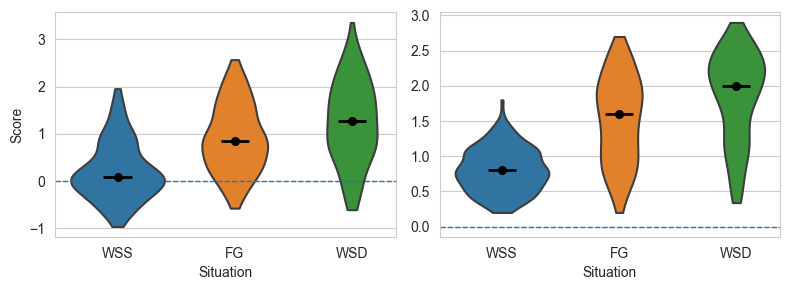

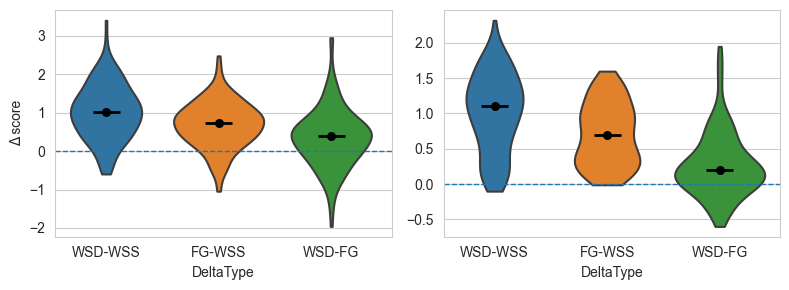

In [14]:
CLS_MAP = {"standard": "WSS", "dialect": "WSD", "FG": "FG"}
CLS_ORDER = ["WSS", "FG", "WSD"]

sns.set_style("whitegrid")


def add_violin_median_markers(ax, df, x_col, y_col, order):
    medians = (
        df.groupby(x_col, observed=False)[y_col]
        .median()
        .reindex(order)
    )

    for i, cat in enumerate(order):
        y = medians.loc[cat]
        if pd.isna(y):
            continue
        ax.scatter(i, y, color="black", s=30, zorder=6)
        ax.hlines(
            y=y,
            xmin=i - 0.12,
            xmax=i + 0.12,
            color="black",
            linewidth=2,
            zorder=6,
        )


def filter_to_common_speakers(df_abs_eds, df_abs_d):
    speakers_eds = set(df_abs_eds["speaker"].dropna().astype(str).str.upper())
    speakers_d = set(df_abs_d["speaker"].dropna().astype(str).str.upper())
    common_speakers = sorted(speakers_eds.intersection(speakers_d))

    df_abs_eds_f = df_abs_eds[df_abs_eds["speaker"].isin(common_speakers)].copy()
    df_abs_d_f = df_abs_d[df_abs_d["speaker"].isin(common_speakers)].copy()
    return df_abs_eds_f, df_abs_d_f, common_speakers


def prepare_within_eds_absolute_df(df, score_col="combined_score"):
    df_abs = df.copy()
    df_abs["speaker"] = df_abs["speaker"].astype(str).str.strip().str.upper()
    df_abs["recording_norm"] = df_abs["recording_condition"].astype(str).str.strip()
    df_abs["Situation"] = df_abs["recording_norm"].map(CLS_MAP)
    df_abs["score"] = pd.to_numeric(df_abs[score_col], errors="coerce")

    df_abs = df_abs.dropna(subset=["speaker", "Situation", "recording_norm", "score"]).copy()

    df_abs = (
        df_abs.groupby(["speaker", "recording_norm", "Situation"], as_index=False)["score"]
        .agg(SEGMENT_AGGREGATION)
    )
    df_abs["Situation"] = pd.Categorical(df_abs["Situation"], categories=CLS_ORDER, ordered=True)

    return df_abs[["speaker", "recording_norm", "Situation", "score"]].copy()


def prepare_dvalue_absolute_df(df):
    df_d_abs = df.copy()
    df_d_abs["speaker"] = df_d_abs["speaker"].astype(str).str.strip().str.upper()
    df_d_abs["recording_norm"] = df_d_abs["recording_condition"].astype(str).str.strip()
    df_d_abs["Situation"] = df_d_abs["recording_norm"].map(CLS_MAP)
    df_d_abs["score"] = pd.to_numeric(df_d_abs["d_value"], errors="coerce")

    df_d_abs = df_d_abs.dropna(subset=["speaker", "recording_norm", "Situation", "score"]).copy()
    df_d_abs["Situation"] = pd.Categorical(df_d_abs["Situation"], categories=CLS_ORDER, ordered=True)

    return df_d_abs[["speaker", "recording_norm", "Situation", "score"]].copy()


def build_delta_df_from_absolute(df_abs):
    wide = df_abs.pivot(index="speaker", columns="Situation", values="score").copy()
    wide = wide.reset_index()

    wide["WSD-WSS"] = wide["WSD"] - wide["WSS"]
    wide["FG-WSS"] = wide["FG"] - wide["WSS"]
    wide["WSD-FG"] = wide["WSD"] - wide["FG"]

    df_delta = wide.melt(
        id_vars=["speaker"],
        value_vars=["WSD-WSS", "FG-WSS", "WSD-FG"],
        var_name="DeltaType",
        value_name="delta",
    )

    delta_order = ["WSD-WSS", "FG-WSS", "WSD-FG"]
    df_delta["DeltaType"] = pd.Categorical(df_delta["DeltaType"], categories=delta_order, ordered=True)
    return wide, df_delta


def prepare_combined_absolute_df(df_abs_eds, df_abs_d):
    df_eds = df_abs_eds.copy()
    df_eds["ScoreType"] = "EDS"

    df_d = df_abs_d.copy()
    df_d["ScoreType"] = "D-value"

    df_combined = pd.concat([df_eds, df_d], ignore_index=True)
    df_combined["ScoreType"] = pd.Categorical(df_combined["ScoreType"], categories=["EDS", "D-value"], ordered=True)
    return df_combined


def prepare_combined_delta_df(df_delta_eds, df_delta_d):
    df1 = df_delta_eds.copy()
    df1["ScoreType"] = "EDS"

    df2 = df_delta_d.copy()
    df2["ScoreType"] = "D-value"

    df_combined = pd.concat([df1, df2], ignore_index=True)
    df_combined["ScoreType"] = pd.Categorical(df_combined["ScoreType"], categories=["EDS", "D-value"], ordered=True)
    return df_combined


def plot_within_absolute_eds_vs_dvalue(df_combined, figsize=(8, 3)):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True)
    score_order = ["EDS", "D-value"]

    for ax, score_type in zip(axes, score_order):
        sub = df_combined[df_combined["ScoreType"] == score_type].copy()

        sns.violinplot(
            data=sub,
            x="Situation",
            y="score",
            order=CLS_ORDER,
            inner=None,
            cut=0,
            ax=ax,
        )

        add_violin_median_markers(ax, sub, x_col="Situation", y_col="score", order=CLS_ORDER)
        ax.axhline(0, linestyle="--", linewidth=1)

        if score_type == "EDS":
            ax.set_ylabel("Score")
        else:
            ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


def plot_within_deltas_eds_vs_dvalue(df_combined_delta, figsize=(8, 3)):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True)

    delta_order = ["WSD-WSS", "FG-WSS", "WSD-FG"]
    score_order = ["EDS", "D-value"]

    for ax, score_type in zip(axes, score_order):
        sub = df_combined_delta[df_combined_delta["ScoreType"] == score_type].copy()

        sns.violinplot(
            data=sub,
            x="DeltaType",
            y="delta",
            order=delta_order,
            inner=None,
            cut=0,
            ax=ax,
        )

        add_violin_median_markers(ax, sub, x_col="DeltaType", y_col="delta", order=delta_order)
        ax.axhline(0, linestyle="--", linewidth=1)

        if score_type == "EDS":
            ax.set_ylabel("Δ score")
        else:
            ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


df_abs_eds_all = prepare_within_eds_absolute_df(segment_scores_df)
df_abs_d_all = prepare_dvalue_absolute_df(d_values_df)
df_abs_eds, df_abs_d, common_speakers = filter_to_common_speakers(df_abs_eds_all, df_abs_d_all)

wide_within, df_delta_eds = build_delta_df_from_absolute(df_abs_eds)
wide_d, df_delta_d = build_delta_df_from_absolute(df_abs_d)

df_combined_abs = prepare_combined_absolute_df(df_abs_eds, df_abs_d)
plot_within_absolute_eds_vs_dvalue(df_combined_abs)

df_combined_delta = prepare_combined_delta_df(df_delta_eds, df_delta_d)
plot_within_deltas_eds_vs_dvalue(df_combined_delta)
